# Imports

In [1]:
import os
import sys

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{bm}", # Recomendado para negritas matemáticas
})

In [3]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [4]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [6]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

### Functions

In [7]:
def create_disk_image_blob_jy_per_pixel(
    N=500,                         # Image size (N x N pixels)
    pixel_scale_arcsec=0.01,       # Pixel scale (0.01 arcsec = 10 mas)
    sigma_core=0.04,               # Gaussian core width (arcsec)
    R_rings=[0.4, 0.6, 0.8],       # Radii of the rings/blobs (arcsec)
    width_rings=[0.05, 0.02, 0.05], # Gaussian width of the rings (arcsec)
    width_blobs=[0.03, 0.03, 0.03], # Width of the localized blobs (arcsec)
    amp_core=0.1,                  # Core amplitude (Jy/pixel)
    amp_rings=[0.05, 0.04, 0.03],  # Rings amplitude (Jy/pixel)
    m_modes=[1, 0, 0],             # Asymmetry mode (1 -> blob, 0 -> ring)
    theta0=[np.pi, 0, 0],     # Blob position angle (radians)
    amp_asym=[0.9, 0, 0]           # Asymmetry/blob amplitude (fraction of amp_rings)
):
    """
    Creates a synthetic disk image directly in Jy/pixel by summing
    Gaussian and annular components in the image plane.
    """
    
    # 1. Prepare coordinate grid and radii
    
    # Pixel coordinates (in arcsec, with center at (0, 0))
    x_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    y_arcsec = (np.arange(N) - N / 2) * pixel_scale_arcsec
    
    # Create the 2D grid of coordinates and radii
    X, Y = np.meshgrid(x_arcsec, y_arcsec)
    R_image = np.sqrt(X**2 + Y**2)
    Phi_image = np.arctan2(Y, X) # Polar angle of each pixel
    
    # Initialize the total image in Jy/pixel
    I_disk_jy_per_pixel = np.zeros((N, N))
    
    # 2. Add the Central Gaussian Core
    
    # 2D Gaussian Formula: I(r) = A * exp(- (r^2 / (2 * sigma^2)))
    # Note: Your original code uses exp(-2 * (pi * sigma * baseline)^2), 
    # which is the FT of a Gaussian. In the image plane, we use the standard form:
    sigma_image = sigma_core / np.sqrt(2 * np.log(2)) # Approximation FWHM -> sigma (Commented out line, original uses sigma_core directly)
    
    I_core = amp_core * np.exp(-0.5 * (R_image / sigma_core)**2)
    I_disk_jy_per_pixel += I_core
    
    # 3. Add Rings and Blobs
    
    # Iterate over the properties of each component
    for A, R, w, w_blob, m, th0, Aasym in zip(amp_rings, R_rings,
                                              width_rings, width_blobs,
                                              m_modes, theta0, amp_asym):
        
        # Symmetric Ring (Gaussian centered at radius R)
        # Formula: I(r) = A * exp(-(r - R)^2 / (2 * w^2))
        I_ring = A * np.exp(-0.5 * ((R_image - R) / w)**2)
        I_disk_jy_per_pixel += I_ring
        
        # Asymmetric Blobs (Displaced Gaussian)
        if m != 0 and Aasym > 0:
            
            # Blob center position (in arcsec)
            x0 = R * np.cos(th0)
            y0 = R * np.sin(th0)
            
            # Coordinate offset
            X_blob = X - x0
            Y_blob = Y - y0
            R_blob_sq = X_blob**2 + Y_blob**2
            
            # Blob amplitude (fraction of the ring)
            A_blob = Aasym * A
            
            # Blob Gaussian (centered at (x0, y0))
            I_blob = A_blob * np.exp(-0.5 * (R_blob_sq / w_blob**2))
            
            I_disk_jy_per_pixel += I_blob
            
    return I_disk_jy_per_pixel

In [8]:
def py_sampleImage(reference_image, dxy, udat, vdat, dRA=0., dDec=0., PA=0., origin='upper'):
    '''
    Original from ``galario``.
    Python implementation of sampleImage.
    
    Args:
        - reference_image: (numpy matrix) Name of the image from where the
                    visibilities will be calculated.
        - dxy: (float) Pixel size in **rad**. 
        - udat: (numpy array) Array with the ``u`` coordinates, in 
                    **wavelength units**.
        - vdat: (numpy array) Array with the ``u`` coordinates, in 
                    **wavelength units**.
        - dRa: (float) Value to shift the visiblities in RA, in **arcsec**.
        - dDec: (float) Value to shift the visiblities in Dec, in **arcsec**.
        - PA: (float) Value to rotate the visibilities, in **rad**.
        - origin: (str) Origin of the coordinate system in the image. It has
                    to be 'lower' or 'upper'.
    '''
    from scipy.interpolate import RectBivariateSpline
    if origin == 'upper':
        v_origin = 1.
    elif origin == 'lower':
        v_origin = -1.
    nxy = reference_image.shape[0]
    dRA *= 2.*np.pi
    dDec *= 2.*np.pi
    du = 1. / (nxy*dxy)
    # Real to Complex transform
    fft_r2c_shifted = np.fft.fftshift(
                        np.fft.rfft2(
                            np.fft.fftshift(reference_image)), axes=0)
    # apply rotation
    cos_PA = np.cos(PA)
    sin_PA = np.sin(PA)
    urot = udat * cos_PA - vdat * sin_PA
    vrot = udat * sin_PA + vdat * cos_PA
    dRArot = dRA * cos_PA - dDec * sin_PA
    dDecrot = dRA * sin_PA + dDec * cos_PA
    # interpolation indices
    uroti = np.abs(urot)/du
    vroti = nxy/2. + v_origin * vrot/du
    uneg = urot < 0.
    vroti[uneg] = nxy/2 - v_origin * vrot[uneg]/du
    # coordinates of FT
    u_axis = np.linspace(0., nxy // 2, nxy // 2 + 1)
    v_axis = np.linspace(0., nxy - 1, nxy)
    # We use RectBivariateSpline to do only linear interpolation, which is faster
    # than interp2d for our case of a regular grid.
    # RectBivariateSpline does not work for complex input, so we need to run it twice.
    f_re = RectBivariateSpline(v_axis, u_axis, fft_r2c_shifted.real, kx=1, ky=1, s=0)
    ReInt = f_re.ev(vroti, uroti)
    f_im = RectBivariateSpline(v_axis, u_axis, fft_r2c_shifted.imag, kx=1, ky=1, s=0)
    ImInt = f_im.ev(vroti, uroti)
    f_amp = RectBivariateSpline(v_axis, u_axis, np.abs(fft_r2c_shifted), kx=1, ky=1, s=0)
    AmpInt = f_amp.ev(vroti, uroti)
    # correct for Real to Complex frequency mapping
    uneg = urot < 0.
    ImInt[uneg] *= -1.
    PhaseInt = np.angle(ReInt + 1j*ImInt)
    # apply the phase change
    theta = urot*dRArot + vrot*dDecrot
    vis = AmpInt * (np.cos(theta+PhaseInt) + 1j*np.sin(theta+PhaseInt))
    return vis

def add_noise_pure(vis, weights=None, seed=93572):
    
    # Default weights
    if weights is None:
        weights = np.ones(vis.shape)

    # Check for complex input
    dim0 = 2 if np.iscomplexobj(vis) else 1

    np.random.seed(seed)

    # Generate noise scaled by weights
    noise = np.random.standard_normal((dim0,) + vis.shape)
    noise *= weights ** -0.5

    # Add noise to real part
    vis_noisy = vis + noise[0]

    # Add noise to imag part
    if np.iscomplexobj(vis):
        vis_noisy += 1j * noise[1]

    return vis_noisy

### Load data

In [9]:

dir = "./../../data/uvtable/"
disk_name = "SimulatedBlob"
data_file = dir +"uvtable_SimulatedBlob.txt"

inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = np.loadtxt(data_file, unpack =True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

In [10]:
q = np.hypot(uvtable['u'], uvtable['v'])
q_min = np.min(q)
q_max = np.max(q)

Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


### UVcoverage

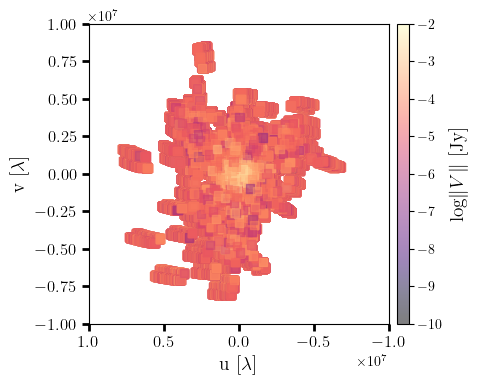

In [11]:
fig = plt.figure(figsize=(4, 4))

ax = fig.add_axes([0.1, 0.1, 0.75, 0.75]) 

log_abs_Vis = np.log(np.abs(Vis))
v_min_color = -10
v_max_color = -2
zoom_factor = 1

scatter = ax.scatter(-u, 
                     -v, 
                     c=log_abs_Vis,
                     marker=',',
                     alpha=0.5,
                     cmap='magma',
                     vmin=v_min_color,
                     vmax=v_max_color)

ax.set_xlim(1e7 / zoom_factor, -1e7 / zoom_factor)
ax.set_ylim(-1e7 / zoom_factor, 1e7/ zoom_factor) 


ax.set_xlabel(r'u [$\lambda$]', size=14)
ax.set_ylabel(r'v [$\lambda$]', size=14)
ax.tick_params(axis='both',    # Puede ser 'x', 'y' o 'both'
               which='major',  # Puede ser 'major', 'minor' o 'both'
               labelsize=12,   # Tamaño de la FUENTE (los números)
               length=5,      # Longitud de la MARCA (la línea)
               width=2)

ax.set_aspect('equal', adjustable='box') 

cb_ax = fig.add_axes([0.87, 0.1, 0.03, 0.75]) 

cbar = plt.colorbar(scatter, cax=cb_ax)
cbar.set_label(r'log$\|V\|$ [Jy]', size=14)


plt.show()

#### Power spectrum

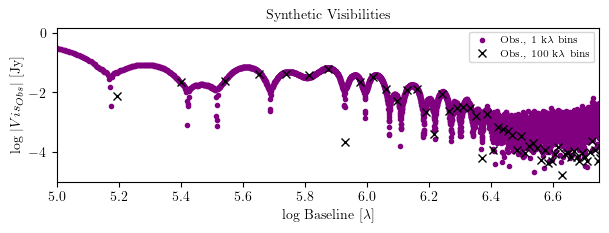

In [12]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V))

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V))


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(7, 2))
plt.plot(logx, logy, marker=ms[0], ls='None', c ='purple', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Synthetic Visibilities", size = 10)
#plt.ylim(-8, 0)
plt.xlim(5, 6.75)
plt.show()

Power spectrum fit: m =  -1 , c =  10000


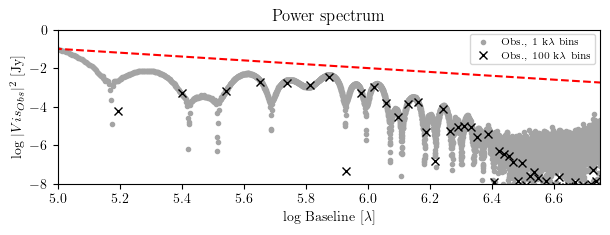

In [13]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(7, 2))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

m = -1
p = -1
logc = p - 5*m
c = 10**logc
print("Power spectrum fit: m = ", m, ", c = ", c)
lgy = linear_power_spectrum(lgx, -1, c)
plt.plot(lgx, lgy, c='red', ls='--')

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
plt.ylim(-8, 0)
plt.xlim(5, 6.75)
plt.show()

### Dirty image

In [14]:
frank2d0 = Frank2D(N, Rmax)

In [15]:
frank2d0.dx

0.009345794392523364

In [16]:
q_min_f2d = np.unique(np.sort(np.hypot(frank2d0.u, frank2d0.v)))[1]
q_max_f2d = np.unique(np.sort(np.hypot(frank2d0.u, frank2d0.v)))[-1]
print(f"-> q_min frank2d: {q_min_f2d}, q_max frank2d: {q_max_f2d}")
print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min frank2d: 48617.081072483736, q_max frank2d: 15606083.02426728
-> q_min data: 11479.355483435862, q_max data: 8828201.715647701


In [17]:
np.sort(frank2d0.FT.q)

array([       0.        ,    34377.46770785,    34377.46770785, ...,
       15581793.44513958, 15581793.44513958, 15606083.02426728])

In [18]:
frank2d0.process_vis(uvtable, hermitian = True)

===>  Setting gridded data...


In [19]:
u, v = frank2d0.gridded_data['u'], frank2d0.gridded_data['v']
vis = frank2d0.gridded_data['vis']
weights = frank2d0.gridded_data['weights']

In [20]:
zoom_factor =1.5

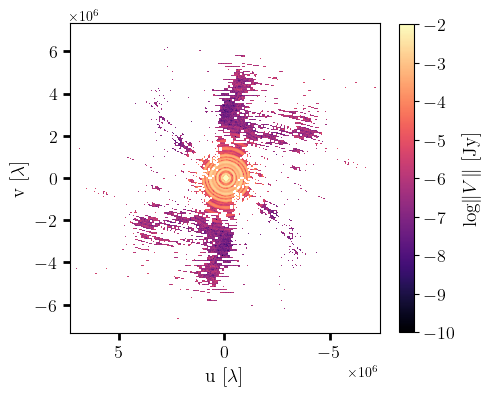

In [21]:
plt.figure(figsize=(5,5))
plt.imshow(np.log(np.abs(vis.reshape(N,N))), 
            extent = [u.max(), u.min(), v.min(), v.max()],
            cmap = 'magma', 
             vmin=-10, vmax=-2)


#plt.title('Synthetic visibilities', size=10)
plt.ylim(v.min()/zoom_factor, v.max()/zoom_factor)
plt.xlim(u.max()/zoom_factor, u.min()/zoom_factor)
plt.xlabel(r'u [$\lambda$]', size=14, weight='extra bold')
plt.ylabel(r'v [$\lambda$]', size=14, weight='extra bold')

cbar = plt.colorbar(shrink=0.8)
cbar.set_label(r'log$\| V \|$ [Jy]', size=14)
cbar.ax.tick_params(labelsize=13)
ax = plt.gca()
ax.tick_params(axis='both', 
               which='major',
               labelsize=13,
               length=5,
               width=2)
plt.show() # Asegúrate de tener esta línea si no usas notebooks

In [39]:
dx = frank2d0.dx/rad_to_arcsec
dy = frank2d0.dy/rad_to_arcsec
pixel_area_in_sr = dx * dy
I_syn_full_Jy_per_sr = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis.reshape(N,N)))).real / pixel_area_in_sr
I_syn_full_Jy_per_pixel = I_syn_full_Jy_per_sr * pixel_area_in_sr

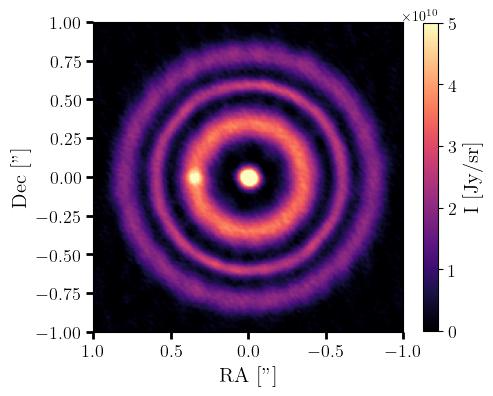

In [42]:
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 1, vmax=5e10, vmin = 0)
plt.figure(figsize=(5,5))
plt.imshow(
            I_syn_full_Jy_per_sr, 
            extent=[frank2d0.Rmax, -frank2d0.Rmax, -frank2d0.Rmax, frank2d0.Rmax],
            norm=norm, 
            cmap = 'magma',
            )

plt.gca().invert_yaxis()
plt.xlim(rout, -rout)
plt.ylim(-rout, rout)
#plt.title('Mock data', size =10)
plt.xlabel(r'RA ["]', size=15, weight='extra bold')
plt.ylabel('Dec ["]', size=15, weight='extra bold')

cbar = plt.colorbar(shrink=0.8)
cbar.set_label(label='I [Jy/sr]', size=15)
cbar.ax.tick_params(labelsize=13)
ax = plt.gca()
ax.tick_params(axis='both', 
               which='major',
               labelsize=13,
               length=5,
               width=2)

### Comparing with full uv-coverage

In [23]:
N = frank2d0.Nx
dx = frank2d0.dx # arcsec
dxy = dx/rad_to_arcsec
type_ ="Blob"
amp_core_ajustado = 0.00025 
amp_rings_ajustado = [0.000086, 0.000070, 0.000050] 
amp_asym_ajustado = [0.65, 0, 0]

reference_image = create_disk_image_blob_jy_per_pixel(
    N=N,                         # Image size (N x N pixels)
    pixel_scale_arcsec=dx,       # Pixel scale (0.01 arcsec = 10 mas)
    sigma_core=0.04,               # Gaussian core width (arcsec)
    R_rings=[0.35, 0.6, 0.8],       # Radii of the rings/blobs (arcsec)
    width_rings=[0.07, 0.03, 0.06], # Gaussian width of the rings (arcsec)
    width_blobs=[0.03, 0.03, 0.03], # Width of the localized blobs (arcsec)
    amp_core=amp_core_ajustado,    # Core amplitude (Jy/pixel)
    amp_rings=amp_rings_ajustado,  # Rings amplitude (Jy/pixel)
    amp_asym=amp_asym_ajustado,
    theta0=[np.pi, 0, 0],
    m_modes=[1, 0, 0])

In [24]:
# Cálculo del área sólida (en sr)
sigma_sr =  (dx/rad_to_arcsec)**2

# Conversión a Jy/sr
image_jy_per_sr = reference_image / sigma_sr

In [25]:
extent = 600*dx/2

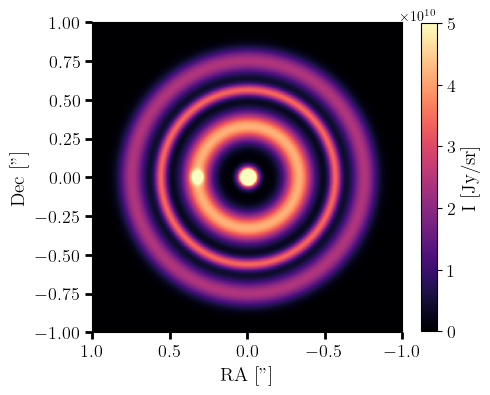

In [27]:
plt.figure(figsize=(5,5))
plt.imshow(image_jy_per_sr, extent=[extent, -extent, -extent, extent], cmap='magma', vmax = 5e10) 
plt.gca().invert_yaxis()
plt.xlim(rout, -rout)
plt.ylim(-rout, rout)
#plt.title('Mock data', size =10)
plt.xlabel('RA ["]', size =14)
plt.ylabel('Dec ["]', size =14)
cbar = plt.colorbar( shrink=0.8)
cbar.set_label(label='I [Jy/sr]', size=14)
cbar.ax.tick_params(labelsize=13)
ax = plt.gca()
ax.tick_params(axis='both', 
               which='major',
               labelsize=13,
               length=5,
               width=2)

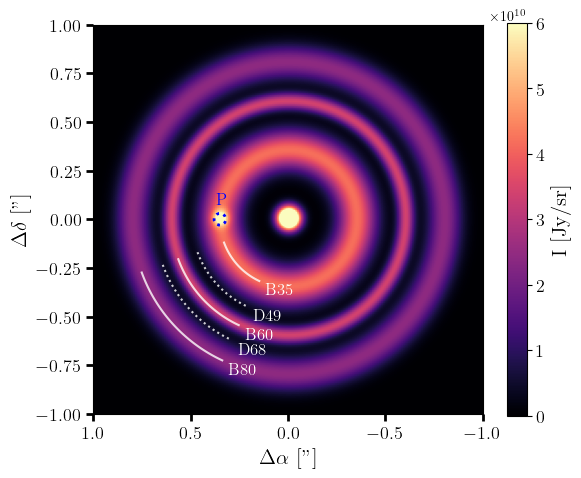

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

blob_R = 0.35       # Radio donde está el blob
blob_theta = np.pi  # Ángulo (180 grados)
blob_width = 0.03   # El 'sigma' del blob

rout = N * dx / 2
extent_cfg = [rout, -rout, -rout, rout]

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(image_jy_per_sr, 
               extent=extent_cfg,
               origin='lower', 
               cmap='magma', 
               vmax=6e10) 

ax.set_xlim(rout, -rout) # Eje X invertido (RA positivo a la izquierda)
ax.set_ylim(-rout, rout)
ax.set_xlabel(r'$\Delta \alpha$ ["]', size=15, weight='extra bold')
ax.set_ylabel(r'$\Delta \delta$ ["]', size=15, weight='extra bold')

def plot_arc(ax, radius, label, style='--', color='white', theta_range=(-20, -65)):
    # theta_range ajustado para que se vea bien en el cuadrante inferior derecho visualmente
    theta = np.linspace(np.radians(theta_range[0]), np.radians(theta_range[1]), 50)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    ax.plot(x, y, color=color, linestyle=style, linewidth=1.5, alpha=0.8)
    # Etiqueta del arco
    ax.text(x[-1]-0.03, y[-1]-0.01, label, color=color, fontsize=12, ha='left', va='top', weight='extra bold')

# Plotear Anillos (B) y Gaps (D)
plot_arc(ax, radius=0.35, label='B35', style='-')
plot_arc(ax, radius=0.60, label='B60', style='-')
plot_arc(ax, radius=0.80, label='B80', style='-')
plot_arc(ax, radius=0.495, label='D49', style=':')
plot_arc(ax, radius=0.685, label='D68', style=':')


blob_x_center = blob_R * np.cos(blob_theta)
blob_y_center = blob_R * np.sin(blob_theta)

highlight_color = 'blue'

circle_blob = patches.Circle(
    (-blob_x_center, 0), # Centro (x,y)
    radius=blob_width,              # Radio definido por tu simulación
    linewidth=2.0,                  # Línea un poco más gruesa
    edgecolor=highlight_color,      # Color del borde
    facecolor='none',               # Sin relleno (transparente por dentro)
    linestyle=':'                   # Línea sólida para resaltar
)

ax.add_patch(circle_blob)

ax.text(-blob_x_center + blob_width - 0.04, blob_y_center + blob_width + 0.03, 
        'P', 
        color=highlight_color, fontsize=12, weight='extra bold', ha='center', va='bottom')


ax.set_xlim(rout/3, -rout/3) # RA positivo a la izquierda
ax.set_ylim(-rout/3, rout/3)

cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label(label='I [Jy/sr]', size=15)
cbar.ax.tick_params(labelsize=13)
ax.tick_params(axis='both', 
               which='major',
               labelsize=13,
               length=5,
               width=2)

plt.tight_layout()
plt.show()

In [40]:
vis_model_perfect = np.fft.ifftshift(np.fft.fft2(np.fft.ifftshift(reference_image)))

Text(0, 0.5, 'v [$\\lambda$]')

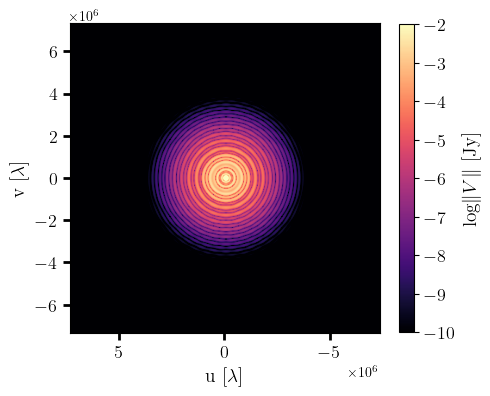

In [50]:
fig = plt.figure(figsize=(5, 5))
plt.imshow(np.log(np.abs(vis_model_perfect.reshape(N,N))), 
            extent = [u.max(), u.min(), v.min(), v.max()],
            cmap = 'magma', 
             vmin=-10, vmax=-2)
#plt.imshow(np.log(np.abs(vis.reshape(N,N))), 
#            extent = [u.max(), u.min(), v.min(), v.max()],
#            cmap = 'magma', 
#             vmin=-10, vmax=-1)


cbar = plt.colorbar(shrink=0.8)
cbar.set_label(r'log$\| V \|$ [Jy]', size=14)
cbar.ax.tick_params(labelsize=13)
ax = plt.gca()
ax.tick_params(axis='both', 
               which='major',
               labelsize=13,
               length=5,
               width=2)
#plt.title('Synthetic visibilities', size=10)
plt.ylim(v.min()/zoom_factor, v.max()/zoom_factor)
plt.xlim(u.max()/zoom_factor, u.min()/zoom_factor)
plt.xlabel(r'u [$\lambda$]', size=14)
plt.ylabel(r'v [$\lambda$]', size=14)

In [42]:
udat, vdat = u, v
model_wspec = weights

In [43]:
#vis_model = py_sampleImage(reference_image, dxy, udat, vdat, dRA=0., dDec=0., PA=0., origin='upper')
#vis_model_noisy = add_noise_pure(vis_model, weights = model_wspec)


### Frank2D

In [10]:
geom = Geometry(0, 0, 0, 0)

In [11]:
N

642

In [12]:
Rmax

3

In [13]:
frank2d2 = Frank2D(N, Rmax)

In [14]:
frank2d2.dx

0.009345794392523364

In [15]:
frank2d2.process_vis(uvtable)

===>  Setting gridded data...


In [16]:
frank2d2.fit( rtol = 1e-10)

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2, 'c': 100000000.0, 'l': 50000.0}
===>  Creating sparse linear system...


        +  Kernel = 0.08  min |  4.69 seconds
        +  Building system = 0.08  min |  4.83 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 245/50000 [00:43<2:26:15,  5.67 iterations/s]


            +  BiCGStab = 0.73  min |  43.75 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 245,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.35  min |  20.75 seconds
--> times building full visibility model = 0.35  min |  20.80 seconds


In [17]:
frank2d2.fit(data = uvtable, rtol = 1e-10)

===>  Creating sparse linear system...


KeyboardInterrupt: 

In [18]:
Plot_ = Plot(frank2d2, geom)

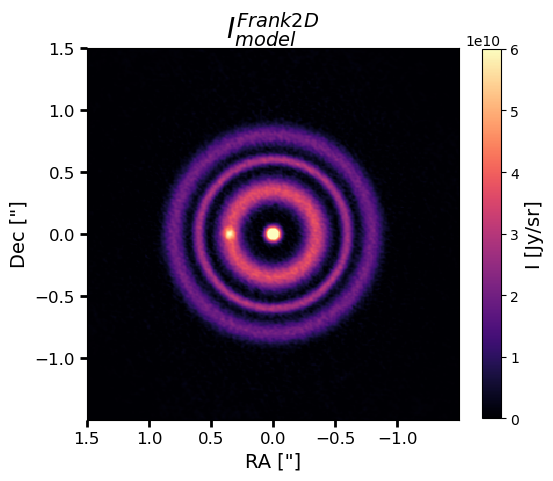

In [22]:
Plot_.intensity(vmax=6e10, gamma = 1, zoom = 2, title = r'$I_{model}^{Frank2D}$')

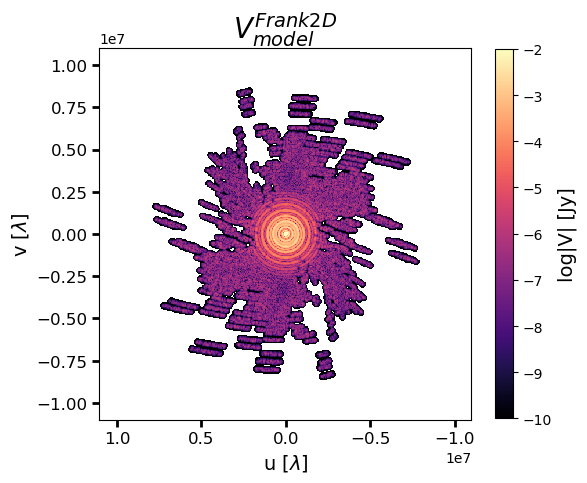

In [21]:
Plot_.visibility(fig_size=6, title= r'$V_{model}^{Frank2D}$')

###  Best

In [68]:
initial_guess = {'p': -1, 'm': -1, 'logl': 4}

In [69]:
frank2d2.search_MAP(initial_guess= initial_guess, N = 50)

Using existing visibility data...
Fitting the visibilities with Frank2D with 2DFT...


 + Time to preprocess the visibilities: 287.91 seconds
--> Calculating m_log_posterior with m, logc, logl: 0 -2.0 4.0
----------- m_log_post: -1015300988.6032605 -----------
Setting the initial guess...
 + Initial guess for the parameters (p, m, l): [-1.0, -1.0, 10000.0]
--> Calculating m_log_posterior with m, logc, logl: -1.0 4.0 4.0
----------- m_log_post: -1015300727.1926627 -----------
 + Initial guess for the parameters (p, m, l): [-2.0, -2.0, 10000.0]
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.0 4.0
----------- m_log_post: -1015303604.3748907 -----------
Optimizing the posterior...
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.0 4.0
----------- m_log_post: -1015303604.3748907 -----------
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.1 4.0
----------- m_log_post: -1015303786.9453533 -----------
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.2618034 4.0
----------- m_log_post: -1015303886.3244125 -----------
--> Calculating m_lo

In [70]:
frank2d2.MAP

{'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}

### Frank2D with best values

In [28]:
best_N50 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}

In [29]:
frank2d3 = Frank2D(N, Rmax)

In [30]:
frank2d3.process_vis(uvtable)

===>  Setting gridded data...


In [31]:
frank2d3.fit(kernel_params = best_N50, rtol = 1e-10) # 1m7s

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...


        +  Kernel = 0.10  min |  5.79 seconds
        +  Building system = 0.10  min |  5.95 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 279/50000 [01:07<3:20:24,  4.14 iterations/s]


            +  BiCGStab = 1.13  min |  67.59 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.07435963551417657,
 'iterations': 279,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.19  min |  11.59 seconds
--> times building full visibility model = 0.19  min |  11.64 seconds


In [32]:
#frank2d3.fit(data = uvtable, kernel_params = best_N50, rtol = 1e-10) # 1m7s

In [36]:
Plot_3 = Plot(frank2d3, geom)

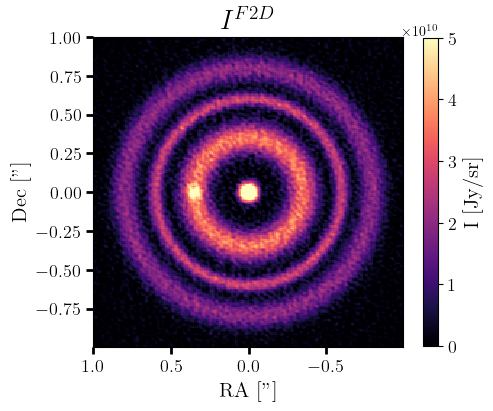

In [37]:
Plot_3.intensity(vmax=5e10, gamma = 1, zoom = 3, title = r'$I^{F2D}$', fig_size=5, label_size=15)

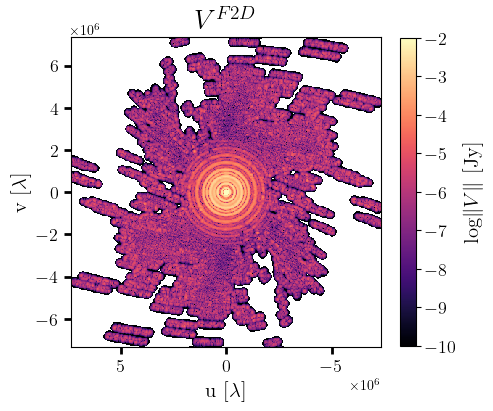

In [38]:
Plot_3.visibility(fig_size=5, zoom = 1.5, vmin = -10,  title = r'$V^{F2D}$', label_size=15)

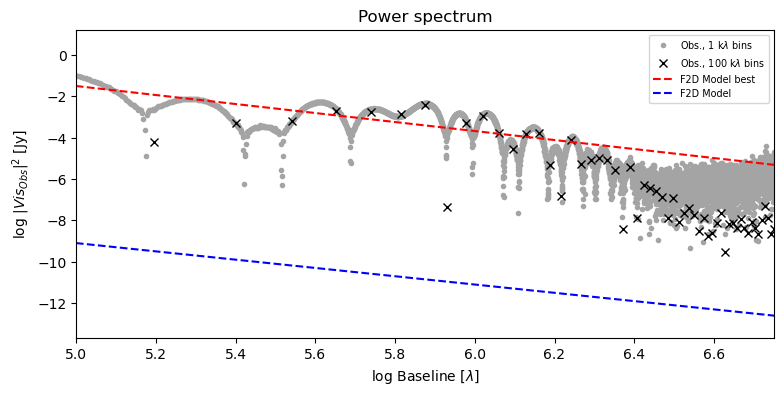

In [17]:
# Analize power spectrum.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = uvtable['u'], uvtable['v']
Vis = uvtable['vis']
Weights = uvtable['weights']

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))


cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 4))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

lgy_best = linear_power_spectrum(lgx, best_N50['m'], best_N50['c'])
lgy_ = linear_power_spectrum(lgx,-2, 8)

plt.plot(lgx, lgy_best, 'r--', label='F2D Model best')
plt.plot(lgx, lgy_, 'b--', label='F2D Model')

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
#plt.ylim(-8, 0)
plt.xlim(5, 6.75)
plt.show()